# Linear Hyperelasticity with full order and reduced order simulation

## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib
# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/syedabidi/Documents/GitHub/scikit-rom


### Standard Imports

In [2]:
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
import src.skrom.problem_classes.master_class_static as master
from src.skrom.utils.visualization.generate_vtk import generate_vtk
importlib.import_module("problem_1.problem_def")   # this runs @register_problem

<module 'problem_1.problem_def' from '/Users/syedabidi/Documents/GitHub/scikit-rom/tests/computational_mechanics/static/linear/problem_1/problem_def.py'>

## Full Order Simulation

In [3]:
generate = True

if generate:
    sim = master.fom_simulation()
    sim.run_simulation()

Snap 1/64 params=[2.98923888 0.34176235]
Snap 2/64 params=[7.89393038 0.26502588]
Snap 3/64 params=[7.00008046 0.39671218]
Snap 4/64 params=[2.09477726 0.22306409]
Snap 5/64 params=[0.64993389 0.35137637]
Snap 6/64 params=[5.86677969 0.23089603]
Snap 7/64 params=[9.33938307 0.31210032]
Snap 8/64 params=[4.12193035 0.28218395]
Snap 9/64 params=[4.79779254 0.37897256]
Snap 10/64 params=[9.85370579 0.20262064]
Snap 11/64 params=[5.21105571 0.33411771]
Snap 12/64 params=[0.15453553 0.26085416]
Snap 13/64 params=[1.522216   0.31377592]
Snap 14/64 params=[6.26526924 0.29369228]
Snap 15/64 params=[8.48663463 0.37430455]
Snap 16/64 params=[3.7429697  0.24478488]
Snap 17/64 params=[3.3501329  0.36670379]
Snap 18/64 params=[8.25447169 0.23998563]
Snap 19/64 params=[6.65871784 0.32177569]
Snap 20/64 params=[1.75376765 0.29809709]
Snap 21/64 params=[0.38669635 0.32643684]
Snap 22/64 params=[5.60389515 0.25593819]
Snap 23/64 params=[9.62215201 0.38703872]
Snap 24/64 params=[4.40434658 0.20715286]
S

### Load Simulation data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/computational_mechanics/static/linear/problem_1/ROM_data


## Data Generation

### Generate Training Solution Dataset

In [5]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Mean Subtraction

In [6]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

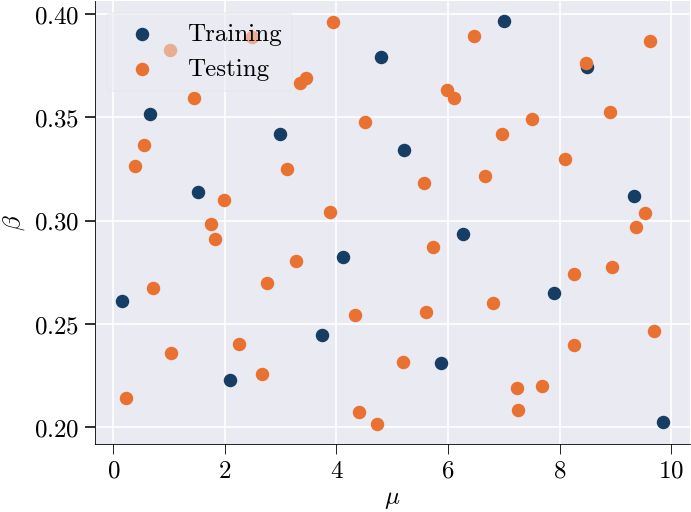

In [7]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on solution snapshots

Number of modes selected: 3


Text(0.5, 0, 'POD modes ($k$)')

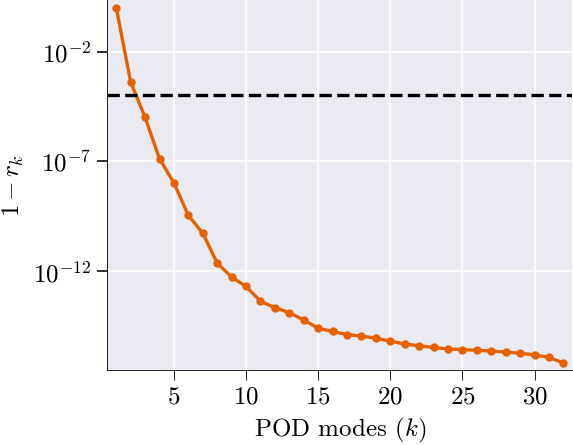

In [8]:
# fig, ax = plt.subplots(figsize=(5,3.5))
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-4, modes=True)
V_sel = U[:, :n_sel]
plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

## ROM Simulation

In [9]:
#Run ROM simulation here:

rom = master.rom_simulation(V_sel = V_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/computational_mechanics/static/linear/problem_1/ROM_data


In [10]:
rom.run_rom_simulation();

Snap 1/64 params=[6.96921779 0.34185052]
Snap 2/64 params=[4.72543476 0.20159383]
Snap 3/64 params=[1.45447157 0.35923454]
Snap 4/64 params=[9.36247505 0.29710133]
Snap 5/64 params=[8.46827627 0.37646658]
Snap 6/64 params=[0.71660922 0.26756365]
Snap 7/64 params=[3.10985765 0.32471002]
Snap 8/64 params=[5.19732452 0.23143057]
Snap 9/64 params=[5.98708861 0.36298543]
Snap 10/64 params=[3.2747025  0.28048326]
Snap 11/64 params=[0.54955168 0.3366195 ]
Snap 12/64 params=[7.67584233 0.2197408 ]
Snap 13/64 params=[9.52701501 0.30385154]
Snap 14/64 params=[2.24454052 0.24020312]
Snap 15/64 params=[3.93330545 0.39584494]
Snap 16/64 params=[6.80185513 0.26032   ]
Snap 17/64 params=[6.46599366 0.38923725]
Snap 18/64 params=[4.33935522 0.25440239]
Snap 19/64 params=[1.98531651 0.30974475]
Snap 20/64 params=[9.69773569 0.24678641]
Snap 21/64 params=[8.09193373 0.32990799]
Snap 22/64 params=[0.22317931 0.21392689]
Snap 23/64 params=[3.45493158 0.36877491]
Snap 24/64 params=[5.73788738 0.28717034]
S

In [11]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

ROM Accuracy Report

Global Errors:
L2 Error:                 6.1336e-04
Relative L2 Error:        3.6398e-06
L∞ Error:                 1.8357e-05
Relative L∞ Error:        5.1428e-06
RMSE:                     7.7285e-07
MAE:                      1.9243e-07

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.6347e-14
95th Percentile Error:    6.5134e-07

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 3.0968e-06
Max Rel L2 Error over time/parameter: 2.5584e-05
Min Rel L2 Error over time/parameter: 9.2842e-08
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

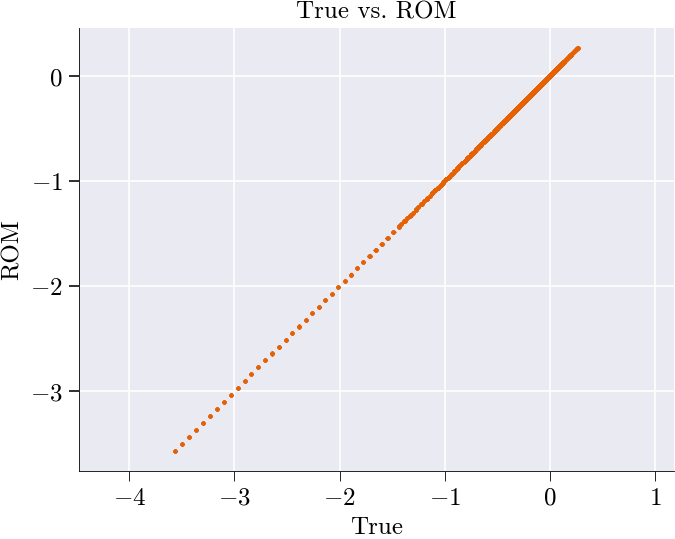

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


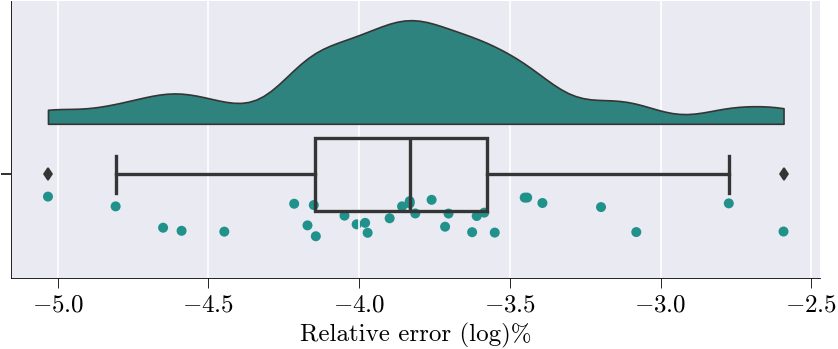

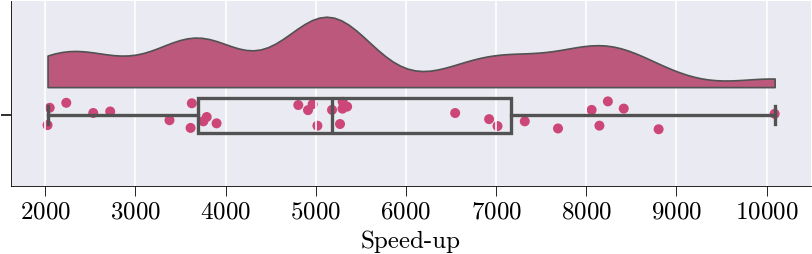

In [12]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

## Visualize on paraview 

In [13]:
generate_vtk(
    LS_test,
    LS_rom,
    sim_data['mesh'].item(),
    sim_data['basis'].item(),
    scale = 1.0,
    num_test = 5,
    out_dir = "sol_vtk_files",
)